In [26]:
#  Install packages
# %conda install -c conda-forge igraph leidenalg matplotlib

In [44]:
"""
Leiden clustering with multiple resolutions as hyperparameters.

Demonstrates how resolution affects cluster granularity and
how to pick the best resolution using modularity.

Requirements:
    pip install leidenalg igraph matplotlib numpy
"""

import igraph as ig
import leidenalg
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [45]:
from utils import build_graph, scan_resolutions, find_best_resolution, plot_results


In [48]:
def subsample_graph(G, percentages=None, seed=42):
    """Subsample vertices from G at different percentages.

    Returns a dict mapping each percentage to the induced subgraph.
    """
    if percentages is None:
        percentages = [0.25, 0.50, 0.75, 1.0]

    rng = np.random.default_rng(seed)
    n_nodes = G.vcount()
    subgraphs = {}

    for pct in percentages:
        k = max(1, int(n_nodes * pct))
        sampled_ids = sorted(rng.choice(n_nodes, size=k, replace=False))
        sub = G.induced_subgraph(sampled_ids)
        subgraphs[pct] = sub
        print(f"Subsample {pct*100:.0f}%: {sub.vcount()} nodes, {sub.ecount()} edges")

    return subgraphs

In [46]:
def build_graph(block_sizes, p_within=0.25, p_between=0.01):
    """Build a synthetic graph with planted community structure (SBM)."""
    n_blocks = len(block_sizes)
    pref_matrix = [[p_within if i == j else p_between
                     for j in range(n_blocks)]
                    for i in range(n_blocks)]
    G = ig.Graph.SBM(pref_matrix, block_sizes)
    print(f"Graph: {G.vcount()} nodes, {G.ecount()} edges\n")
    return G

In [49]:
# 1. Build graph
G = build_graph(block_sizes=[40, 35, 30, 25])
# 2. Subsample vertices at different percentages
subgraphs = subsample_graph(G, percentages=[0.50, 0.75, 1.0])

Graph: 130 nodes, 595 edges

Subsample 50%: 65 nodes, 132 edges
Subsample 75%: 97 nodes, 331 edges
Subsample 100%: 130 nodes, 595 edges


In [54]:
def scan_resolutions(G, resolutions, seed=42):
    """Run Leiden clustering across a range of resolutions."""
    records = []
    for res in resolutions:
        partition = leidenalg.find_partition(
            G,
            leidenalg.RBConfigurationVertexPartition,
            resolution_parameter=res,
            seed=seed,
        )
        membership = np.array(partition.membership)
        n_clusters = len(set(membership))
        modularity = G.modularity(partition.membership)

        records.append({
            "resolution": res,
            "n_clusters": n_clusters,
            "modularity": modularity,
            "membership": membership,
        })
        print(f"res={res:.2f}  clusters={n_clusters:>3}  "
              f"modularity={modularity:.4f}")
    return records


def find_best_resolution(records):
    """Identify the resolution with the highest modularity."""
    best = max(records, key=lambda r: r["modularity"])
    print(f"\nBest modularity:  res={best['resolution']:.2f} "
          f"(Q={best['modularity']:.4f}, {best['n_clusters']} clusters)")
    return best


def plot_results(G, records, best_mod, pick_resolutions=None,
                 outfile="leiden_resolutions"):
    """Plot clusters/modularity vs resolution and network layouts."""
    if pick_resolutions is None:
        pick_resolutions = [0.3, 1.0, 2.0]

    fig = plt.figure(figsize=(5, 10))
    gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)
    res_vals = [r["resolution"] for r in records]

    # ── Top: dual-axis clusters & modularity ──
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(res_vals, [r["n_clusters"] for r in records], "o-",
             color="tab:blue", label="# clusters")
    ax1_mod = ax1.twinx()
    ax1_mod.plot(res_vals, [r["modularity"] for r in records], "s-",
                 color="tab:green", label="modularity")
    ax1_mod.axvline(best_mod["resolution"], ls=":", color="tab:green", alpha=0.6)
    ax1.set_xlabel("Resolution")
    ax1.set_ylabel("Number of clusters", color="tab:blue")
    ax1_mod.set_ylabel("Modularity (Q)", color="tab:green")
    ax1.set_title("Clusters & Modularity vs Resolution")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1_mod.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

   
    fig.suptitle("Leiden Clustering: Resolution as Hyperparameter",
                 fontsize=12, y=0.98)
    plt.savefig(f"{outfile}.png", dpi=150, bbox_inches="tight")
    # plt.savefig(f"{outfile}.pdf", bbox_inches="tight")
    print(f"\nSaved: {outfile}.png")




── Subsample 50% (65 nodes) ──
res=0.10  clusters=  4  modularity=0.5932
res=0.20  clusters=  4  modularity=0.5932
res=0.30  clusters=  4  modularity=0.5932
res=0.40  clusters=  4  modularity=0.5932
res=0.50  clusters=  5  modularity=0.6455
res=0.60  clusters=  5  modularity=0.6455
res=0.70  clusters=  5  modularity=0.6455
res=0.80  clusters=  5  modularity=0.6455
res=0.90  clusters=  5  modularity=0.6455
res=1.00  clusters=  5  modularity=0.6455
res=1.10  clusters=  5  modularity=0.6455
res=1.20  clusters=  5  modularity=0.6455
res=1.30  clusters=  5  modularity=0.6455
res=1.40  clusters=  5  modularity=0.6455
res=1.50  clusters=  7  modularity=0.6130
res=1.60  clusters=  9  modularity=0.5894
res=1.70  clusters=  9  modularity=0.5894
res=1.80  clusters=  9  modularity=0.5894
res=1.90  clusters=  9  modularity=0.5894
res=2.00  clusters=  9  modularity=0.5894
res=2.10  clusters=  9  modularity=0.5742
res=2.20  clusters=  9  modularity=0.5742
res=2.30  clusters= 11  modularity=0.5461
re

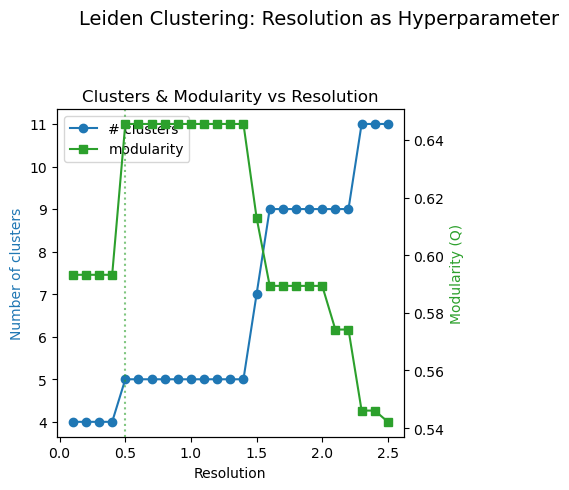

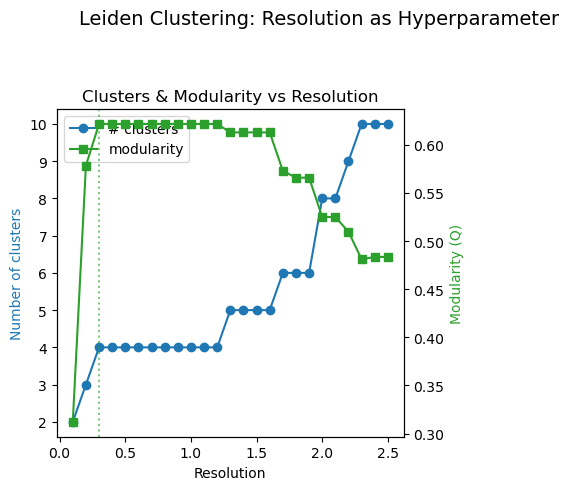

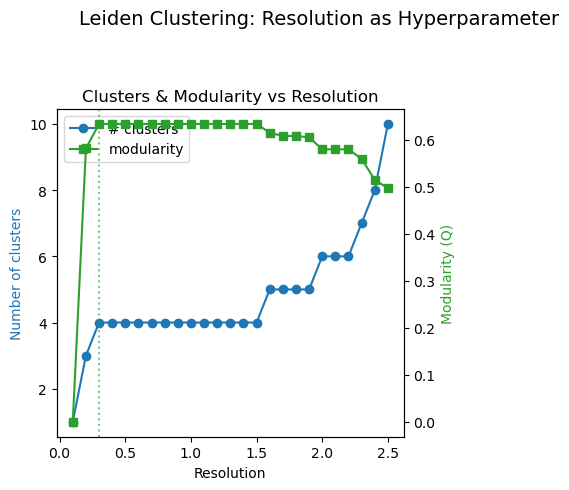

In [55]:
    # 3. Scan resolutions on each subsampled graph
    np.random.seed(42)
    resolutions = np.round(np.arange(0.1, 2.51, 0.1), 2)
    for pct, sub_G in subgraphs.items():
        print(f"\n── Subsample {pct*100:.0f}% ({sub_G.vcount()} nodes) ──")
        records = scan_resolutions(sub_G, resolutions)
        best_mod = find_best_resolution(records)

        # 4. Plot results per subsample
        plot_results(sub_G, records, best_mod,
                     outfile=f"leiden_resolutions_{int(pct*100)}pct")